In [71]:
import csv

import pandas as pd
import geopandas as gpd
import networkx as nx
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import json

# Set seed, relevant for visualizations
rng = np.random.default_rng(seed=10)

# Load data

In [2]:
# Load IOM DTM Somalia dataset Feb-Oct 2025
df_dtm = pd.read_excel('data/IOM_DTM_ETT_SOM_Tracker_sinceFeb2025_w19.xlsx')    # TODO: load only necesary columns
df_dtm.head(3)

,Date of Assessment,Region Name,District Name,OCHA Region Pcode,OCHA District Pcode,Operational Zone,Catchment,Settlement Name,Settlement ID,Location Type,...,Needs - Temporary Learning Classes,Needs - CCCM Site improvement,Needs - CCCM Complaints and Feedback Mechanism,Needs - CCCM Site Decongestion,Needs - CCCM Plot Allocation,Data Collection Week,Origin_Destination,Origin_Region_country,Origin_District_country,Reason of Displacement
0,2025-06-16,Galgaduud,Cabudwaaq,SO19,SO1902,OPZ 211,NaN,Canjiidle,DTM-SO1902-12769,Urban (Waah/Neighborhood),...,No,No,No,No,No,"Week 19 (14 - 18 June, 2025)",OC,Ethiopia,Ethiopia,Drought
1,2025-06-14,Bay,Baidoa,SO24,SO2401,OPZ 179,CA02,Wadajir 6 Jinaay,DTM-SO2401-11287,Urban (Waah/Neighborhood),...,No,No,No,No,No,"Week 19 (14 - 18 June, 2025)",OR,Bakool,Waajid,Drought
2,2025-06-14,Galgaduud,Dhuusamarreeb,SO19,SO1901,OPZ 226,NaN,Dalab,DTM-SO1901-6596,Urban (Waah/Neighborhood),...,No,No,No,No,No,"Week 19 (14 - 18 June, 2025)",OR,Hiraan,Bulo Burto,Drought


In [3]:
sorted(df_dtm['Data Collection Week'].unique())

['Week 01 (8-12 February, 2025)',
 'Week 02 (15-19 February, 2025)',
 'Week 03 (22-26 February, 2025)',
 'Week 04 (1-5 March, 2025)',
 'Week 05 (8-12 March, 2025)',
 'Week 06 (15-19 March, 2025)',
 'Week 07 (22-26 March, 2025)',
 'Week 08 (29 March - 2 April, 2025)',
 'Week 09 (5 - 9 April, 2025)',
 'Week 10 (12 - 16 April, 2025)',
 'Week 11 (19 - 23 April, 2025)',
 'Week 12 (26 - 30 April, 2025)',
 'Week 13 (3 - 7 May, 2025)',
 'Week 14 (10 - 14 May, 2025)',
 'Week 15 (17 - 21 May, 2025)',
 'Week 16 (24 - 28 May, 2025)',
 'Week 17 (31 May - 04 June, 2025)',
 'Week 18 (8 - 11 June, 2025)',
 'Week 19 (14 - 18 June, 2025)']

In [69]:
# Load GADM dataset
gdf_gadm = gpd.read_file('data/gadm41_SOM_2.json.zip')
gdf_gadm = gdf_gadm.to_crs('epsg:20539') # centroids are obtained with more accuracy using a projected CRS
gdf_gadm['centroid'] = gdf_gadm.centroid

gdf_gadm.head(10)

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,centroid
0,SOM.1.1_1,SOM,Somalia,SOM.1_1,Awdal,NA,Baki,NA,NA,District,District,NA,SO.AW.BA,"MULTIPOLYGON (((-258918.643 1178983.263, -2583...",POINT (-297818.987 1143950.621)
1,SOM.1.2_1,SOM,Somalia,SOM.1_1,Awdal,NA,Boorama,Boramo|Borama,NA,District,District,NA,SO.AW.BO,"MULTIPOLYGON (((-346944.62 1076389.937, -34730...",POINT (-360144.965 1134011.013)
2,SOM.1.3_1,SOM,Somalia,SOM.1_1,Awdal,NA,Lughaya,Lughaye,NA,District,District,NA,SO.AW.LU,"MULTIPOLYGON (((-258918.643 1178983.263, -3287...",POINT (-313798.554 1184798.15)
3,SOM.1.4_1,SOM,Somalia,SOM.1_1,Awdal,NA,Zeylac,Saylac,NA,District,District,NA,SO.AW.ZE,"MULTIPOLYGON (((-324555.621 1265736.823, -3240...",POINT (-358373.583 1213809.07)
4,SOM.2.1_1,SOM,Somalia,SOM.2_1,Bakool,NA,CeelBarde,CeelBarde|ElBarde,NA,District,District,NA,SO.BK.CB,"MULTIPOLYGON (((-376869.554 515682.202, -37312...",POINT (-279257.958 519284.885)
5,SOM.2.2_1,SOM,Somalia,SOM.2_1,Bakool,NA,RabDhuure,NA,NA,District,District,NA,NA,"MULTIPOLYGON (((-415552.598 476651.148, -41270...",POINT (-367586.636 472230.654)
6,SOM.2.3_1,SOM,Somalia,SOM.2_1,Bakool,NA,Tiyeeglow,Tiyeglow,NA,District,District,NA,SO.BK.TI,"MULTIPOLYGON (((-248297.756 493015.914, -20253...",POINT (-220429.668 426550.603)
7,SOM.2.4_1,SOM,Somalia,SOM.2_1,Bakool,NA,Wajid,NA,NA,District,District,NA,SO.BK.WA,"MULTIPOLYGON (((-379728.332 438518.577, -31912...",POINT (-342316.943 424914.394)
8,SOM.2.5_1,SOM,Somalia,SOM.2_1,Bakool,NA,Xudur,Hudur,NA,District,District,NA,SO.BK.HU,"MULTIPOLYGON (((-360080.658 498573.536, -24829...",POINT (-290018.079 466205.742)
9,SOM.3.1_1,SOM,Somalia,SOM.3_1,Banaadir,NA,Mogadisho,Mogadishu,NA,District,District,NA,NA,"MULTIPOLYGON (((-100881.743 242321.793, -10243...",POINT (-120940.991 234184.971)


# Districts

In [5]:
# In using 'Somalia District of Origin' we ignore "Ethiopia" and "Other" values, but have to remove NaNs
origin_districts = df_dtm['Somalia District of Origin'][df_dtm['Somalia District of Origin'].notna()].unique()  
origin_districts

array(['Waajid', 'Bulo Burto', 'Diinsoor', 'Xudur', 'Garoowe',
       'Adan Yabaal', 'Balcad', 'Saakow', 'Qansax Dheere', 'Qoryooley',
       'Belet Weyne', 'Baardheere', 'Baidoa', "Bu'Aale", 'Jalalaqsi',
       'Jamaame', 'Gaalkacyo', 'Afgooye', 'Jowhar', 'Ceel Dheer',
       'Cabudwaaq', 'Luuq', 'Kismaayo', 'Rab Dhuure', 'Kurtunwaarey',
       'Cadale', 'Buur Hakaba', 'Badhaadhe', 'Ceel Barde', 'Ceel Buur',
       'Garbahaarey', 'Tayeeglow', 'Afmadow', 'Dhuusamarreeb',
       'Belet Xaawo', 'Dharkenley', 'Hobyo', 'Marka', 'Taleex', 'Jilib',
       'Ceel Waaq', 'Bossaso', 'Wanla Weyn', 'Baraawe', 'Doolow',
       'Sablaale', 'Hodan', 'Xarardheere', 'Wardhigley', 'Hamar Jabjab',
       'Jariiban', 'Ceerigaabo', 'Dayniile', 'Galdogob', 'Kahda', 'Eyl',
       'Shangaani', 'Hawl Wadaag', 'Qardho', 'Cadaado', 'Laasqoray',
       'Burtinle', 'Laas Caanood', 'Huriwaa', 'Qandala', 'Zeylac',
       'Waaberi', 'Caluula', 'Shibis', 'Wadajir (Medina)', 'Caynabo'],
      dtype=object)

In [6]:
destination_districts = df_dtm['District Name'].unique()
destination_districts

array(['Cabudwaaq', 'Baidoa', 'Dhuusamarreeb', 'Diinsoor', 'Xudur',
       'Garoowe', 'Hodan', 'Baardheere', 'Dayniile', "Bu'Aale",
       'Qansax Dheere', 'Balcad', 'Belet Weyne', 'Kismaayo', 'Gaalkacyo',
       'Waajid', 'Afgooye', 'Jowhar', 'Doolow', 'Bulo Burto', 'Luuq',
       'Kahda', 'Afmadow', 'Belet Xaawo', 'Jamaame'], dtype=object)

In [7]:
set(destination_districts) - set(origin_districts)

set()

There are no destination districts that are not also origin districts (origins are superset)

In [8]:
districts_dtm = origin_districts.tolist()
print(f"Number of districts in DTM data: {len(districts_dtm)}")

Number of districts in DTM data: 71


In [9]:
# District names as per GADM level 2
districts_gadm = gdf_gadm['NAME_2'].to_numpy()
districts_gadm.sort()
districts_gadm = list(districts_gadm)
districts_gadm

['Aadan',
 'Afgooye',
 'Afmadow',
 'Baar-Dheere',
 'Badhaadhe',
 'Badhan',
 'Baki',
 'Balcad',
 'Bander-Beyla',
 'Baraawe',
 'Baydhabo',
 'BeledWeyn',
 'BeledXaawo',
 'Berbera',
 'Boorama',
 'Bosaaso',
 "Bu'aale",
 'Burao',
 'Burtinle',
 'Buuhoodle',
 'BuuloBurdo',
 'BuurXakaba',
 'Caabudwaaq',
 'Cadaado',
 'Cadale',
 'Calawla',
 'Caynabo',
 'Ceel-Afwein',
 'CeelBarde',
 'CeelBuur',
 'CeelDheer',
 'CeelWaaq',
 'Ceerigaabo',
 'Dhuusamareeb',
 'Diinsoor',
 'Dolow',
 'Eyl',
 'Gaalkacayo',
 'Gabiley',
 'Garbahaaray',
 'Garoowe',
 'Goldogob',
 'Hargeysa',
 'Hobyo',
 'Iskushuban',
 'Jalalaqsi',
 'Jamaame',
 'Jariiban',
 'Jawhar',
 'Jilib',
 'Kismaayo',
 'Kuntuwaaray',
 'Lascaanod',
 'Lughaya',
 'Luuk',
 'Marka',
 'Mogadisho',
 'Oodweyne',
 'Qandala',
 'QansaxDheere',
 'Qardho',
 'Qoryooley',
 'RabDhuure',
 'Saakow',
 'Sablale',
 'Sheekh',
 'Taleex',
 'Tiyeeglow',
 'Wajid',
 'WanlaWeyn',
 'Xarardheere',
 'Xudun',
 'Xudur',
 'Zeylac']

In [10]:
print(f"Number of districts in GADM level 2: {len(districts_gadm)}")

Number of districts in GADM level 2: 74


## Plot districts in GADM

0: Baki
1: Boorama
2: Lughaya
3: Zeylac
4: CeelBarde
5: RabDhuure
6: Tiyeeglow
7: Wajid
8: Xudur
9: Mogadisho
10: Bander-Beyla
11: Bosaaso
12: Calawla
13: Iskushuban
14: Qandala
15: Qardho
16: Baydhabo
17: BuurXakaba
18: Diinsoor
19: QansaxDheere
20: Caabudwaaq
21: Cadaado
22: CeelBuur
23: CeelDheer
24: Dhuusamareeb
25: Baar-Dheere
26: BeledXaawo
27: CeelWaaq
28: Dolow
29: Garbahaaray
30: Luuk
31: BeledWeyn
32: BuuloBurdo
33: Jalalaqsi
34: Bu'aale
35: Jilib
36: Saakow
37: Afmadow
38: Badhaadhe
39: Jamaame
40: Kismaayo
41: Gaalkacayo
42: Goldogob
43: Hobyo
44: Jariiban
45: Xarardheere
46: Burtinle
47: Eyl
48: Garoowe
49: Badhan
50: Ceel-Afwein
51: Ceerigaabo
52: Aadan
53: Balcad
54: Cadale
55: Jawhar
56: Afgooye
57: Baraawe
58: Kuntuwaaray
59: Marka
60: Qoryooley
61: Sablale
62: WanlaWeyn
63: Caynabo
64: Lascaanod
65: Taleex
66: Xudun
67: Burao
68: Buuhoodle
69: Oodweyne
70: Sheekh
71: Berbera
72: Gabiley
73: Hargeysa


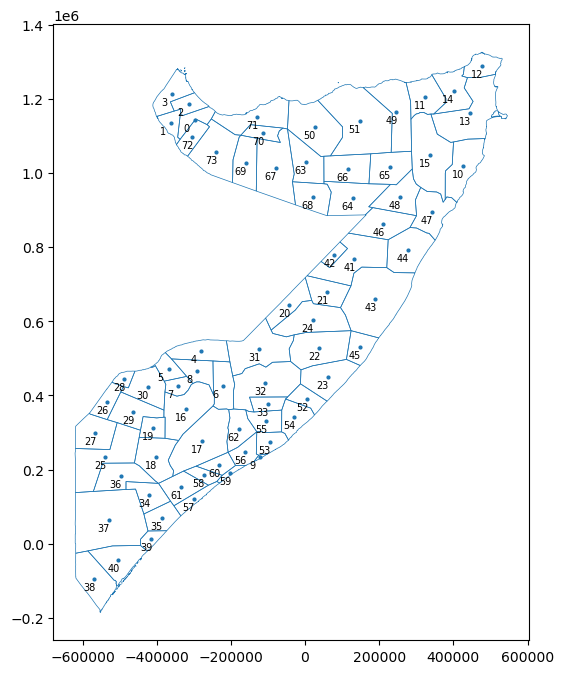

In [ ]:
fig, ax = plt.subplots(1, figsize=(8,8))
gdf_gadm.boundary.plot(ax=ax, linewidth=0.5)
gdf_gadm.set_geometry('centroid').plot(ax=ax, markersize=4)

for idx, row in gdf_gadm.iterrows():
    point = row['centroid']
    x = point.x
    y = point.y
    ax.annotate(
        idx, xy=(x,y), 
        color='k', 
        xycoords='data',
        xytext=(-8, -8), 
        textcoords='offset points', 
        fontsize=7
    )

## District matching


On district names...

From Wikipedia [Administrative divisions of Somalia](https://en.wikipedia.org/wiki/Administrative_divisions_of_Somalia):
- 72 districts (no source)

Individual District pages (e.g. [Gabiley District](https://en.wikipedia.org/wiki/Gabiley_District)) cite following source: [Districts of Somalia](https://www.statoids.com/yso.html) by [Statoids](https://www.statoids.com/statoids.html) website, which seems to be a personal website, although published a book [*Administrative Divisions of Countries*](https://openlibrary.org/books/OL8138355M/Administrative_Subdivisions_of_Countries).
- Shows district names along with [**HASC** geocodes](https://en.wikipedia.org/wiki/Geocode#Hierarchical_naming) (dated 1990).
- Cites as source related to the Somalia National Peace Conference, but link is broken.

The DTM data provides [OCHA **P-codes**](https://knowledge.base.unocha.org/wiki/spaces/imtoolbox/pages/222265609/P-codes).

Could not find an easily accessible mapping from HASC to P-codes.

There is a dataset named [*World Bank Global Administrative Divisions*](https://gee-community-catalog.org/projects/wb_gad/) which seems to in general have attributes to level 2 admin areas in both HASC and P-code.

### GADM data

In [12]:
# Match districts in DTM to GADM via least edit distance

from Levenshtein import distance as edit_distance

district_matches_gadm = {}

for district_name in districts_dtm :
    distances_to_gadm_names = {x : edit_distance(district_name, x) for x in districts_gadm}
    # distances_to_gadm_names = {x : edit_distance(district_name, x) for x in districts_wb}
    closest_match, d = min(distances_to_gadm_names.items(), key=lambda x : x[1])
    district_matches_gadm[district_name] = (closest_match, d)

print(district_matches_gadm)

{'Waajid': ('Wajid', 1), 'Bulo Burto': ('BuuloBurdo', 3), 'Diinsoor': ('Diinsoor', 0), 'Xudur': ('Xudur', 0), 'Garoowe': ('Garoowe', 0), 'Adan Yabaal': ('Qandala', 7), 'Balcad': ('Balcad', 0), 'Saakow': ('Saakow', 0), 'Qansax Dheere': ('QansaxDheere', 1), 'Qoryooley': ('Qoryooley', 0), 'Belet Weyne': ('BeledWeyn', 3), 'Baardheere': ('Baar-Dheere', 2), 'Baidoa': ('Badhan', 3), "Bu'Aale": ("Bu'aale", 1), 'Jalalaqsi': ('Jalalaqsi', 0), 'Jamaame': ('Jamaame', 0), 'Gaalkacyo': ('Gaalkacayo', 1), 'Afgooye': ('Afgooye', 0), 'Jowhar': ('Jawhar', 1), 'Ceel Dheer': ('CeelDheer', 1), 'Cabudwaaq': ('Caabudwaaq', 1), 'Luuq': ('Luuk', 1), 'Kismaayo': ('Kismaayo', 0), 'Rab Dhuure': ('RabDhuure', 1), 'Kurtunwaarey': ('Kuntuwaaray', 3), 'Cadale': ('Cadale', 0), 'Buur Hakaba': ('BuurXakaba', 2), 'Badhaadhe': ('Badhaadhe', 0), 'Ceel Barde': ('CeelBarde', 1), 'Ceel Buur': ('CeelBuur', 1), 'Garbahaarey': ('Garbahaaray', 1), 'Tayeeglow': ('Tiyeeglow', 1), 'Afmadow': ('Afmadow', 0), 'Dhuusamarreeb': ('Dhuusa

In [13]:
# Print closely matching names
close_matches = {name : match for name, match in district_matches_gadm.items() if match[1] <= 3}
print(f"Total of {len(close_matches)} ({len(close_matches)/len(districts_dtm):.0%}) DTM names have exact or close matches (0 <= d <= 3) in GADM:")
longest_name_length = len(max(close_matches.keys(), key=len))
for name, match in sorted(close_matches.items(), key=lambda x: x[1][1]):
    print(f"{name:<{longest_name_length}} --> {match[0]:<15} (d = {match[1]})")

Total of 58 (82%) DTM names have exact or close matches (0 <= d <= 3) in GADM:
Diinsoor      --> Diinsoor        (d = 0)
Xudur         --> Xudur           (d = 0)
Garoowe       --> Garoowe         (d = 0)
Balcad        --> Balcad          (d = 0)
Saakow        --> Saakow          (d = 0)
Qoryooley     --> Qoryooley       (d = 0)
Jalalaqsi     --> Jalalaqsi       (d = 0)
Jamaame       --> Jamaame         (d = 0)
Afgooye       --> Afgooye         (d = 0)
Kismaayo      --> Kismaayo        (d = 0)
Cadale        --> Cadale          (d = 0)
Badhaadhe     --> Badhaadhe       (d = 0)
Afmadow       --> Afmadow         (d = 0)
Hobyo         --> Hobyo           (d = 0)
Marka         --> Marka           (d = 0)
Taleex        --> Taleex          (d = 0)
Jilib         --> Jilib           (d = 0)
Baraawe       --> Baraawe         (d = 0)
Xarardheere   --> Xarardheere     (d = 0)
Jariiban      --> Jariiban        (d = 0)
Ceerigaabo    --> Ceerigaabo      (d = 0)
Eyl           --> Eyl             (d = 

In [14]:
# Print poorly matching names
poor_matches = {name : match for name, match in district_matches_gadm.items() if match[1] > 3}
print(f"Total of {len(poor_matches)} ({len(poor_matches)/len(districts_dtm):.0%}) DTM names have no close matches in GADM (d > 3):")
longest_name_length = len(max(poor_matches.keys(), key=len))
for name, match in sorted(poor_matches.items(), key=lambda x: x[1][1]):
    print(f"{name:<{longest_name_length}} --> {match[0]:<15} (d = {match[1]})")

Total of 13 (18%) DTM names have no close matches in GADM (d > 3):
Laas Caanood     --> Lascaanod       (d = 4)
Huriwaa          --> Burao           (d = 4)
Waaberi          --> Berbera         (d = 4)
Shibis           --> Jilib           (d = 4)
Wardhigley       --> Gabiley         (d = 5)
Dayniile         --> Burtinle        (d = 5)
Dharkenley       --> Burtinle        (d = 6)
Shangaani        --> Aadan           (d = 6)
Laasqoray        --> Gaalkacayo      (d = 6)
Adan Yabaal      --> Qandala         (d = 7)
Hawl Wadaag      --> Balcad          (d = 7)
Hamar Jabjab     --> Hargeysa        (d = 8)
Wadajir (Medina) --> Wajid           (d = 11)


### World Bank data

In [15]:
# Load WB Admin2 additional attributes
wb_admin2_attr_file = 'data/WB_Official_Boundaries_Admin2_additional_columns.csv'

df_wb = pd.read_csv(wb_admin2_attr_file)
df_wb.head(3)

/var/folders/xp/mdkzlytn4qv_lz4v46jhdptw0000gn/T/ipykernel_12088/3133050960.py:4: DtypeWarning: Columns (3,11,12,20,22,23) have mixed types. Specify dtype option on import or set low_memory=False.
  df_wb = pd.read_csv(wb_admin2_attr_file)


,ADM2CD_c,HASC_0,HASC_1,HASC_2,GAUL_0,GAUL_1,GAUL_2,SOVEREIGN,NAM_1_GAUL,NAM_1_STAT,...,P_CODE_2,P_CODE_2_t,P_NAME_2,ADM2CD,ADM2CD_t,ADM2NM,P_DATE,SALB_DATE,P_CODE_2_c,P_CODE_1_c
0,CHN001006,CN,CN.AH,NaN,147295,898,12984,CHN,Anhui Sheng,Anhui,...,CN034070,NaN,Hefei,NaN,CHN001006,NaN,2020-09-10,NaN,CN034070,CN034
1,CHN001002,CN,CN.AH,NaN,147295,898,12986,CHN,Anhui Sheng,Anhui,...,CN034020,NaN,Bengbu,NaN,CHN001002,NaN,2020-09-10,NaN,CN034020,CN034
2,CHN001008,CN,CN.AH,NaN,147295,898,12987,CHN,Anhui Sheng,Anhui,...,CN034090,NaN,Huainan,NaN,CHN001008,NaN,2020-09-10,NaN,CN034090,CN034


In [16]:
# Filter to Somalia entries
df_wb_som = df_wb[df_wb['HASC_0'] == 'SO']
df_wb_som.head(3)

,ADM2CD_c,HASC_0,HASC_1,HASC_2,GAUL_0,GAUL_1,GAUL_2,SOVEREIGN,NAM_1_GAUL,NAM_1_STAT,...,P_CODE_2,P_CODE_2_t,P_NAME_2,ADM2CD,ADM2CD_t,ADM2NM,P_DATE,SALB_DATE,P_CODE_2_c,P_CODE_1_c
6522,SOM001001,SO,SO.AW,NaN,226,2688,25653,SOM,Awdal,Awdal,...,SO1102,NaN,Baki,NaN,SOM001001,NaN,1984-06-23,NaN,SO1102,SO11
6523,SOM001002,SO,SO.AW,NaN,226,2688,25654,SOM,Awdal,Awdal,...,SO1101,NaN,Borama,NaN,SOM001002,NaN,1984-06-23,NaN,SO1101,SO11
6524,SOM001003,SO,SO.AW,NaN,226,2688,25655,SOM,Awdal,Awdal,...,SO1103,NaN,Lughaye,NaN,SOM001003,NaN,1984-06-23,NaN,SO1103,SO11


Matches the number of districts in GADM data

In [17]:
df_wb_som.HASC_2.unique()

array([nan], dtype=object)

No HASC admin level 2 codes....

In [18]:
# Extract district names
districts_wb = df_wb_som.P_NAME_2[df_wb_som.P_NAME_2.notnull()].tolist()
districts_wb

['Baki',
 'Borama',
 'Lughaye',
 'Zeylac',
 'Ceel Barde',
 'Rab Dhuure',
 'Tayeeglow',
 'Waajid',
 'Xudur',
 'Bandarbeyla',
 'Bossaso',
 'Caluula',
 'Iskushuban',
 'Qandala',
 'Qardho',
 'Cabudwaaq',
 'Cadaado',
 'Ceel Buur',
 'Ceel Dheer',
 'Dhuusamarreeb',
 'Doolow',
 'Luuq',
 'Belet Weyne',
 'Bulo Burto',
 'Jalalaqsi',
 'Gaalkacyo',
 'Galdogob',
 'Hobyo',
 'Jariiban',
 'Xarardheere',
 'Burtinle',
 'Eyl',
 'Garoowe',
 'Laasqoray',
 'Ceel Afweyn',
 'Ceerigaabo',
 'Adan Yabaal',
 'Balcad',
 'Cadale',
 'Jowhar',
 'Afgooye',
 'Marka',
 'Qoryooley',
 'Wanla Weyn',
 'Caynabo',
 'Laas Caanood',
 'Taleex',
 'Xudun',
 'Burco',
 'Buuhoodle',
 'Owdweyne',
 'Sheikh',
 'Berbera',
 'Gebiley',
 'Hargeysa',
 'Baydhaba',
 'Buur Hakaba',
 'Diinsoor',
 'Qansax Dheere',
 'Baardheere',
 'Belet Xaawo',
 'Ceel Waaq',
 'Garbahaarey',
 "Bu'aale",
 'Jilib',
 'Saakow',
 'Afmadow',
 'Badhaadhe',
 'Jamaame',
 'Kismaayo',
 'Baraawe',
 'Kurtunwaarey',
 'Sablaale']

In [19]:
len(districts_wb)

73

In [20]:
sum(df_wb_som.P_NAME_2.isna())

1

Not sure what the one NaN entry is about

In [21]:
# Match districts in DTM to WB via least edit distance (by name)

from Levenshtein import distance as edit_distance

district_matches_wb = {}

for district_name in districts_dtm :
    distances_to_gadm_names = {x : edit_distance(district_name, x) for x in districts_wb}
    # distances_to_gadm_names = {x : edit_distance(district_name, x) for x in districts_dtm}
    closest_match, d = min(distances_to_gadm_names.items(), key=lambda x : x[1])
    district_matches_wb[district_name] = (closest_match, d)

print(district_matches_wb)

{'Waajid': ('Waajid', 0), 'Bulo Burto': ('Bulo Burto', 0), 'Diinsoor': ('Diinsoor', 0), 'Xudur': ('Xudur', 0), 'Garoowe': ('Garoowe', 0), 'Adan Yabaal': ('Adan Yabaal', 0), 'Balcad': ('Balcad', 0), 'Saakow': ('Saakow', 0), 'Qansax Dheere': ('Qansax Dheere', 0), 'Qoryooley': ('Qoryooley', 0), 'Belet Weyne': ('Belet Weyne', 0), 'Baardheere': ('Baardheere', 0), 'Baidoa': ('Baki', 4), "Bu'Aale": ("Bu'aale", 1), 'Jalalaqsi': ('Jalalaqsi', 0), 'Jamaame': ('Jamaame', 0), 'Gaalkacyo': ('Gaalkacyo', 0), 'Afgooye': ('Afgooye', 0), 'Jowhar': ('Jowhar', 0), 'Ceel Dheer': ('Ceel Dheer', 0), 'Cabudwaaq': ('Cabudwaaq', 0), 'Luuq': ('Luuq', 0), 'Kismaayo': ('Kismaayo', 0), 'Rab Dhuure': ('Rab Dhuure', 0), 'Kurtunwaarey': ('Kurtunwaarey', 0), 'Cadale': ('Cadale', 0), 'Buur Hakaba': ('Buur Hakaba', 0), 'Badhaadhe': ('Badhaadhe', 0), 'Ceel Barde': ('Ceel Barde', 0), 'Ceel Buur': ('Ceel Buur', 0), 'Garbahaarey': ('Garbahaarey', 0), 'Tayeeglow': ('Tayeeglow', 0), 'Afmadow': ('Afmadow', 0), 'Dhuusamarreeb':

In [22]:
# Print closely matching names
close_matches = {name : match for name, match in district_matches_wb.items() if 0 <= match[1] <= 3}
print(f"Total of {len(close_matches)} ({len(close_matches)/len(districts_dtm):.0%} of) DTM names have exact or close matches (0 <= d <= 3) in WB:")
longest_name_length = len(max(close_matches.keys(), key=len))
for name, match in sorted(close_matches.items(), key=lambda x: x[1][1]):
    print(f"{name:<{longest_name_length}} --> {match[0]:<15} (d = {match[1]})")

Total of 60 (85% of) DTM names have exact or close matches (0 <= d <= 3) in WB:
Waajid        --> Waajid          (d = 0)
Bulo Burto    --> Bulo Burto      (d = 0)
Diinsoor      --> Diinsoor        (d = 0)
Xudur         --> Xudur           (d = 0)
Garoowe       --> Garoowe         (d = 0)
Adan Yabaal   --> Adan Yabaal     (d = 0)
Balcad        --> Balcad          (d = 0)
Saakow        --> Saakow          (d = 0)
Qansax Dheere --> Qansax Dheere   (d = 0)
Qoryooley     --> Qoryooley       (d = 0)
Belet Weyne   --> Belet Weyne     (d = 0)
Baardheere    --> Baardheere      (d = 0)
Jalalaqsi     --> Jalalaqsi       (d = 0)
Jamaame       --> Jamaame         (d = 0)
Gaalkacyo     --> Gaalkacyo       (d = 0)
Afgooye       --> Afgooye         (d = 0)
Jowhar        --> Jowhar          (d = 0)
Ceel Dheer    --> Ceel Dheer      (d = 0)
Cabudwaaq     --> Cabudwaaq       (d = 0)
Luuq          --> Luuq            (d = 0)
Kismaayo      --> Kismaayo        (d = 0)
Rab Dhuure    --> Rab Dhuure      (d =

In [23]:
# Print poorly matching names
poor_matches = {name : match for name, match in district_matches_wb.items() if match[1] > 3}
print(f"Total of {len(poor_matches)} ({len(poor_matches)/len(districts_dtm):.0%} of) DTM names have no close matches in WB (d > 3):")
longest_name_length = len(max(poor_matches.keys(), key=len))
for name, match in sorted(poor_matches.items(), key=lambda x: x[1][1]):
    print(f"{name:<{longest_name_length}} --> {match[0]:<15} (d = {match[1]})")

Total of 11 (15% of) DTM names have no close matches in WB (d > 3):
Baidoa           --> Baki            (d = 4)
Waaberi          --> Waajid          (d = 4)
Shibis           --> Sheikh          (d = 4)
Dayniile         --> Qandala         (d = 5)
Shangaani        --> Sablaale        (d = 5)
Huriwaa          --> Borama          (d = 5)
Dharkenley       --> Burtinle        (d = 6)
Wardhigley       --> Qardho          (d = 6)
Hawl Wadaag      --> Ceel Waaq       (d = 6)
Hamar Jabjab     --> Adan Yabaal     (d = 7)
Wadajir (Medina) --> Waajid          (d = 10)


Now we have the P-code of districts connected to a name that closely matches the name in GADM. We can connect these P-codes to the names in our data.

Then we basically have the mapping GADM names (& geometry) -> WB names -> WB Pcodes -> DTM Pcodes -> DTM names

The problem is that the DTM data doesn't have Pcodes for origin districts. Perhaps this could be solved by the data from the DTM api?

(BTW we could also just use the geo data from the world bank, instead of GADM altogether. Although that might not solve our problems.)

### Create mapping dict

In [24]:
# import csv

# wb_to_gadm_id = {}
# wb_to_gadm_name = {}
# with open('data/region_mapping-gadm_wb-centroid.csv', 'r') as f :
#     reader = csv.reader(f)
#     print(next(reader)) # Skip header
#     for gadm_id, wb_id, dist, gadm_name, wb_name in reader :
#         wb_to_gadm_id[wb_id] = gadm_id
#         wb_to_gadm_name[wb_name] = gadm_name

In [25]:
# Initial mapping DTM to WB by zero-distance names; print rest

dtm_to_wb_name = {}
unmatched_dtm_names = []
unmatched_wb_names = districts_wb.copy()
for dtm_name, (wb_name, d) in sorted(district_matches_wb.items(), key=lambda x: x[0]) :
    if d <= 1 :
        dtm_to_wb_name[dtm_name] = wb_name
        unmatched_wb_names.remove(wb_name)
    else :
        unmatched_dtm_names.append(dtm_name)

for k, v in dtm_to_wb_name.items() :
    print(f"{k:>15} --> {v}")
print(f"Unmatched DTM names ({len(unmatched_dtm_names)}): {unmatched_dtm_names}")
print(f"Unmatched WB names ({len(unmatched_wb_names)}):  {unmatched_wb_names}")

    Adan Yabaal --> Adan Yabaal
        Afgooye --> Afgooye
        Afmadow --> Afmadow
     Baardheere --> Baardheere
      Badhaadhe --> Badhaadhe
         Balcad --> Balcad
        Baraawe --> Baraawe
    Belet Weyne --> Belet Weyne
    Belet Xaawo --> Belet Xaawo
        Bossaso --> Bossaso
        Bu'Aale --> Bu'aale
     Bulo Burto --> Bulo Burto
       Burtinle --> Burtinle
    Buur Hakaba --> Buur Hakaba
      Cabudwaaq --> Cabudwaaq
        Cadaado --> Cadaado
         Cadale --> Cadale
        Caluula --> Caluula
        Caynabo --> Caynabo
     Ceel Barde --> Ceel Barde
      Ceel Buur --> Ceel Buur
     Ceel Dheer --> Ceel Dheer
      Ceel Waaq --> Ceel Waaq
     Ceerigaabo --> Ceerigaabo
  Dhuusamarreeb --> Dhuusamarreeb
       Diinsoor --> Diinsoor
         Doolow --> Doolow
            Eyl --> Eyl
      Gaalkacyo --> Gaalkacyo
       Galdogob --> Galdogob
    Garbahaarey --> Garbahaarey
        Garoowe --> Garoowe
          Hobyo --> Hobyo
      Jalalaqsi --> Jalalaqsi
 

In [26]:
# Manually set rest of mappings

dtm_to_wb_name.update({
    'Baidoa':       'Baydhaba',     # From wikipedia https://en.wikipedia.org/wiki/Baidoa
    'Dharkenley':   'nan',          # Neighbourhood of Mogadishu, but WB does not have Mogadishu (AKA Xamar/Hamar) or Banaadir (region name) (https://en.wikipedia.org/wiki/Mogadishu)
    'Hodan':        'nan',          # Neighbourhood of Mogadishu
    'Wardhigley':   'nan',          # Neighbourhood of Mogadishu
    'Hamar Jabjab': 'nan',          # Neighbourhood of Mogadishu
    'Dayniile':     'nan',          # Neighbourhood of Mogadishu
    'Kahda':        'nan',          # Neighbourhood of Mogadishu
    'Shangaani':    'nan',          # Neighbourhood of Mogadishu
    'Hawl Wadaag':  'nan',          # Neighbourhood of Mogadishu
    'Huriwaa':      'nan',          # Neighbourhood of Mogadishu
    'Waaberi':      'nan',          # Neighbourhood of Mogadishu
    'Shibis':       'nan',          # Neighbourhood of Mogadishu
    'Wadajir (Medina)': 'nan'       # Neighbourhood of Mogadishu
})

In [27]:
dtm_to_wb_name

{'Adan Yabaal': 'Adan Yabaal',
 'Afgooye': 'Afgooye',
 'Afmadow': 'Afmadow',
 'Baardheere': 'Baardheere',
 'Badhaadhe': 'Badhaadhe',
 'Balcad': 'Balcad',
 'Baraawe': 'Baraawe',
 'Belet Weyne': 'Belet Weyne',
 'Belet Xaawo': 'Belet Xaawo',
 'Bossaso': 'Bossaso',
 "Bu'Aale": "Bu'aale",
 'Bulo Burto': 'Bulo Burto',
 'Burtinle': 'Burtinle',
 'Buur Hakaba': 'Buur Hakaba',
 'Cabudwaaq': 'Cabudwaaq',
 'Cadaado': 'Cadaado',
 'Cadale': 'Cadale',
 'Caluula': 'Caluula',
 'Caynabo': 'Caynabo',
 'Ceel Barde': 'Ceel Barde',
 'Ceel Buur': 'Ceel Buur',
 'Ceel Dheer': 'Ceel Dheer',
 'Ceel Waaq': 'Ceel Waaq',
 'Ceerigaabo': 'Ceerigaabo',
 'Dhuusamarreeb': 'Dhuusamarreeb',
 'Diinsoor': 'Diinsoor',
 'Doolow': 'Doolow',
 'Eyl': 'Eyl',
 'Gaalkacyo': 'Gaalkacyo',
 'Galdogob': 'Galdogob',
 'Garbahaarey': 'Garbahaarey',
 'Garoowe': 'Garoowe',
 'Hobyo': 'Hobyo',
 'Jalalaqsi': 'Jalalaqsi',
 'Jamaame': 'Jamaame',
 'Jariiban': 'Jariiban',
 'Jilib': 'Jilib',
 'Jowhar': 'Jowhar',
 'Kismaayo': 'Kismaayo',
 'Kurtunwaa

In [28]:
# Output dict to json
json.dump(dtm_to_wb_name, open('data/dtm_to_wb_name.json', 'w'), indent=4)

In [29]:
# Initial mapping DTM to GADM by zero-distance names; print rest

dtm_to_gadm_name = {}
unmatched_dtm_names = []
unmatched_gadm_names = districts_gadm.copy()
for dtm_name, (gadm_name, d) in sorted(district_matches_gadm.items(), key=lambda x: x[0]) :
    if d <= 1 :
        dtm_to_gadm_name[dtm_name] = gadm_name
        unmatched_gadm_names.remove(gadm_name)
    else :
        unmatched_dtm_names.append(dtm_name)

for k, v in dtm_to_gadm_name.items() :
    print(f"{k:>15} --> {v}")
print(f"Unmatched DTM names ({len(unmatched_dtm_names)}): {unmatched_dtm_names}")
print(f"Unmatched GADM names ({len(unmatched_gadm_names)}):  {unmatched_gadm_names}")

        Afgooye --> Afgooye
        Afmadow --> Afmadow
      Badhaadhe --> Badhaadhe
         Balcad --> Balcad
        Baraawe --> Baraawe
        Bossaso --> Bosaaso
        Bu'Aale --> Bu'aale
       Burtinle --> Burtinle
      Cabudwaaq --> Caabudwaaq
        Cadaado --> Cadaado
         Cadale --> Cadale
        Caynabo --> Caynabo
     Ceel Barde --> CeelBarde
      Ceel Buur --> CeelBuur
     Ceel Dheer --> CeelDheer
      Ceel Waaq --> CeelWaaq
     Ceerigaabo --> Ceerigaabo
  Dhuusamarreeb --> Dhuusamareeb
       Diinsoor --> Diinsoor
         Doolow --> Dolow
            Eyl --> Eyl
      Gaalkacyo --> Gaalkacayo
       Galdogob --> Goldogob
    Garbahaarey --> Garbahaaray
        Garoowe --> Garoowe
          Hobyo --> Hobyo
      Jalalaqsi --> Jalalaqsi
        Jamaame --> Jamaame
       Jariiban --> Jariiban
          Jilib --> Jilib
         Jowhar --> Jawhar
       Kismaayo --> Kismaayo
           Luuq --> Luuk
          Marka --> Marka
        Qandala --> Qandala
  Qan

In [30]:
# Manually set rest of mappings

dtm_to_gadm_name.update({
    'Baardheere':   'Baar-Dheere',
    'Belet Weyne':  'BeledWeyn',
    'Belet Xaawo':  'BeledXaawo',
    'Bulo Burto':   'BuuloBurdo',
    'Buur Hakaba':  'BuurXakaba',
    'Laas Caanood': 'Lascaanod',
    'Kurtunwaarey': 'Kuntuwaaray', 
    'Adan Yabaal':  'Aadan',        # Somali name https://en.wikipedia.org/wiki/Adan_Yabal_District
    'Baidoa':       'Baydhabo',     # From wikipedia https://en.wikipedia.org/wiki/Baidoa, 
    'Caluula':      'Calawla',      # Wikipedia: https://en.wikipedia.org/wiki/Alula%2C_Somalia, does not exactly state the equivalence, but all searches for "Calawla" redirect to "Alula" == "Caluula" (Somali)
    'Laasqoray':    'Badhan',       # Could only find a reference to "Las Qoray" as a town in the Badhan district https://en.wikipedia.org/wiki/Las_Khorey
    'Dayniile':     'Mogadisho',    # Neighbourhood of Mogadishu, but WB does not have Mogadishu (AKA Xamar/Hamar) or Banaadir (region name) (https://en.wikipedia.org/wiki/Mogadishu)
    'Dharkenley':   'Mogadisho',    # Neighbourhood of Mogadishu
    'Hamar Jabjab': 'Mogadisho',    # Neighbourhood of Mogadishu
    'Hawl Wadaag':  'Mogadisho',    # Neighbourhood of Mogadishu
    'Hodan':        'Mogadisho',    # Neighbourhood of Mogadishu
    'Huriwaa':      'Mogadisho',    # Neighbourhood of Mogadishu
    'Kahda':        'Mogadisho',    # Neighbourhood of Mogadishu
    'Shangaani':    'Mogadisho',    # Neighbourhood of Mogadishu
    'Shibis':       'Mogadisho',    # Neighbourhood of Mogadishu
    'Waaberi':      'Mogadisho',    # Neighbourhood of Mogadishu
    'Wardhigley':   'Mogadisho',    # Neighbourhood of Mogadishu
    'Wadajir (Medina)': 'Mogadisho', # Neighbourhood of Mogadishu
})

# Still unmated from GADM: ['Baki', 'Bander-Beyla', 'Berbera', 'Boorama', 'Burao', 'Buuhoodle', 'Ceel-Afwein', 'Gabiley', 'Hargeysa', 'Iskushuban', 'Lughaya', 'Oodweyne', 'Sheekh', 'Xudun']
# Probably because missing from DTM data (i.e. not observed as source or destination district)

With this mapping, we are compressing the information about the capital (Mogadishu) neighbourhoods. We need to decide how important this is to keep. (Can check below how much flow in/out of neighbourhood districts.)

We could probably enrich the data from GADM with the neighbourhoods of Mogadishu using OSM?

In [31]:
# Output dict to json
json.dump(dtm_to_gadm_name, open('data/dtm_to_gadm_name.json', 'w'), indent=4)

# Flows

In [32]:
# Create directed graph with flows aggregated over all weeks
g_all_weeks = nx.DiGraph()
g_all_weeks.add_nodes_from(districts_dtm)

for origin in districts_dtm :
    points_origin = df_dtm[df_dtm['Origin_District_country'] == origin]
    # for destination in districts_dtm :
    for destination in destination_districts :
        # print(points_origin['District Name'].unique())
        if destination in points_origin['District Name'].values :  # If this district was a destination for this origin
            points_origin_dest = points_origin[points_origin['District Name'] == destination]
            total_arrivals = points_origin_dest['Total new arrivals since last week'].sum()

            g_all_weeks.add_edge(origin, destination, weight=total_arrivals)

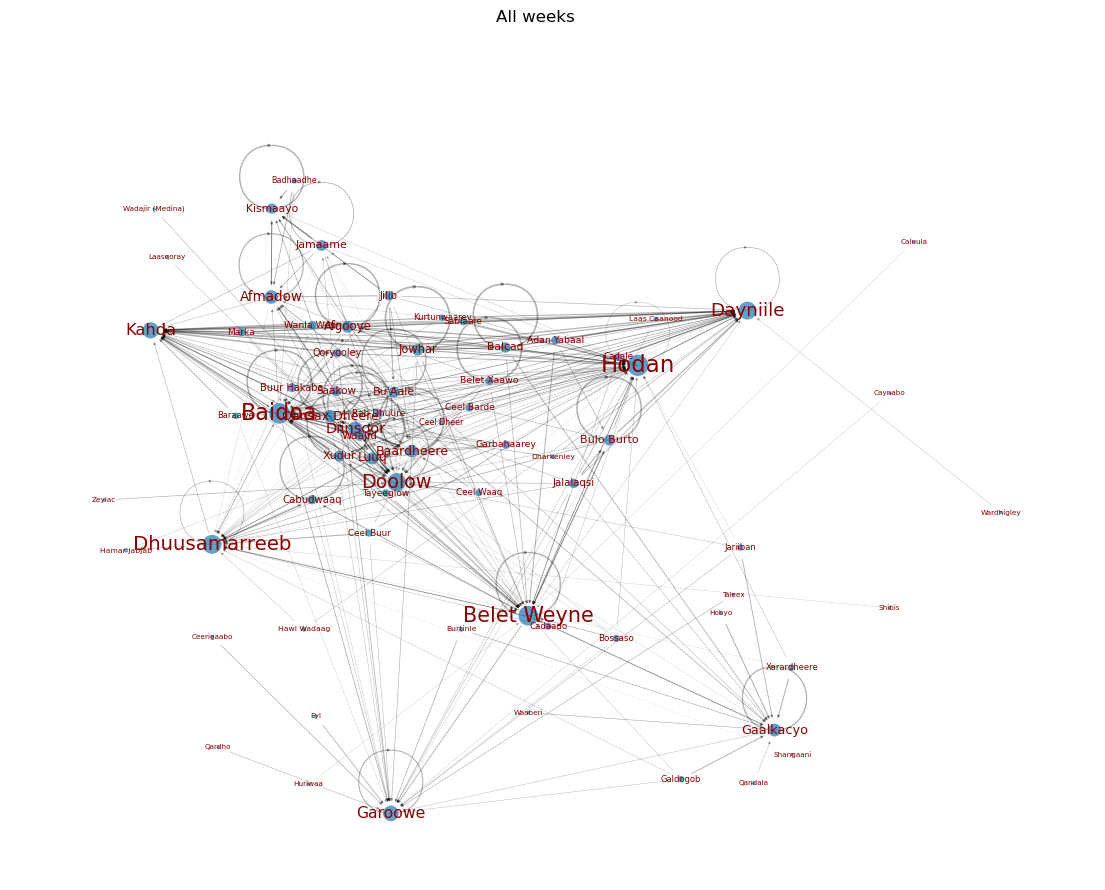

In [33]:
# Plot graph

pos_params = dict(
    weight='weight', 
    method='force', 
    # gravity=1,
    k=2,
    iterations=50,
    center=(0,0)
)

def plot_flow_graph(
    g, ax, 
    *,
    pos=None,
    with_labels=True,
    no_self_loops=False,
    node_sizes=None,
    node_params={'alpha': 0.7},
    edge_colors=None,
    edge_width_func=lambda w : np.log(w) / 8,
    edge_params={'alpha': 0.3},
):
    if pos is None:
        pos = nx.spring_layout(g, **pos_params)
    
    if node_sizes is None:
        node_sizes = [1 + g.in_degree(n) * 5 for n in g.nodes()]

    node_draw_params = dict(node_params)
    node_draw_params.update(
        node_size=node_sizes,
        linewidths=0,
    )
    nx.draw_networkx_nodes(g, pos=pos, ax=ax, **node_draw_params)

    if no_self_loops:
        edge_widths = [edge_width_func(d["weight"]) if u != v else 0 for u, v, d in g.edges(data=True)]
    else:
        edge_widths = [edge_width_func(d["weight"]) for u, v, d in g.edges(data=True)]

    if edge_colors is None:
        edge_colors = "Black"

    edge_draw_params = dict(edge_params)
    edge_draw_params.update(
        width=edge_widths,
        edge_color=edge_colors,
        arrowsize=4,
    )
    nx.draw_networkx_edges(g, pos=pos, ax=ax, **edge_draw_params)

    if with_labels:
        font_sizes = {n: 5 + g.degree(n) / 4 for n in g.nodes()}
        nx.draw_networkx_labels(
            g, pos=pos, ax=ax,
            font_size=font_sizes,
            font_color="DarkRed",
        )

    ax.axis("off")
    
fig, ax = plt.subplots(1, figsize=(14,10))

pos_all_weeks = nx.spring_layout(g_all_weeks, seed=10, **pos_params)
# pos_all_weeks = nx.random_layout(g_all_weeks)
# pos_all_weeks = nx.circular_layout(g_all_weeks)

node_sizes_all_weeks = [1 + g_all_weeks.degree(n) * 5 for n in g_all_weeks.nodes()]
plot_flow_graph(g_all_weeks, ax, pos=pos_all_weeks, node_sizes=node_sizes_all_weeks)

xlim_all_weeks = ax.get_xlim()
ylim_all_weeks = ax.get_ylim()

fig.suptitle('All weeks');

In [34]:
# Create directed flow graphs per week

g_per_week = []
weeks = sorted(df_dtm['Data Collection Week'].unique())

for i, week in enumerate(weeks) :
    g = nx.DiGraph()
    g.add_nodes_from(districts_dtm)

    df_week = df_dtm[df_dtm['Data Collection Week'] == week]
    for origin in districts_dtm :
        points_origin = df_week[df_week['Origin_District_country'] == origin]
        for destination in destination_districts :
            if destination in points_origin['District Name'].values :
                points_origin_dest = points_origin[points_origin['District Name'] == destination]
                total_arrivals = points_origin_dest['Total new arrivals since last week'].sum()

                g.add_edge(origin, destination, weight=total_arrivals)

    g_per_week.append(g)

g_per_week[0].nodes()

NodeView(('Waajid', 'Bulo Burto', 'Diinsoor', 'Xudur', 'Garoowe', 'Adan Yabaal', 'Balcad', 'Saakow', 'Qansax Dheere', 'Qoryooley', 'Belet Weyne', 'Baardheere', 'Baidoa', "Bu'Aale", 'Jalalaqsi', 'Jamaame', 'Gaalkacyo', 'Afgooye', 'Jowhar', 'Ceel Dheer', 'Cabudwaaq', 'Luuq', 'Kismaayo', 'Rab Dhuure', 'Kurtunwaarey', 'Cadale', 'Buur Hakaba', 'Badhaadhe', 'Ceel Barde', 'Ceel Buur', 'Garbahaarey', 'Tayeeglow', 'Afmadow', 'Dhuusamarreeb', 'Belet Xaawo', 'Dharkenley', 'Hobyo', 'Marka', 'Taleex', 'Jilib', 'Ceel Waaq', 'Bossaso', 'Wanla Weyn', 'Baraawe', 'Doolow', 'Sablaale', 'Hodan', 'Xarardheere', 'Wardhigley', 'Hamar Jabjab', 'Jariiban', 'Ceerigaabo', 'Dayniile', 'Galdogob', 'Kahda', 'Eyl', 'Shangaani', 'Hawl Wadaag', 'Qardho', 'Cadaado', 'Laasqoray', 'Burtinle', 'Laas Caanood', 'Huriwaa', 'Qandala', 'Zeylac', 'Waaberi', 'Caluula', 'Shibis', 'Wadajir (Medina)', 'Caynabo'))

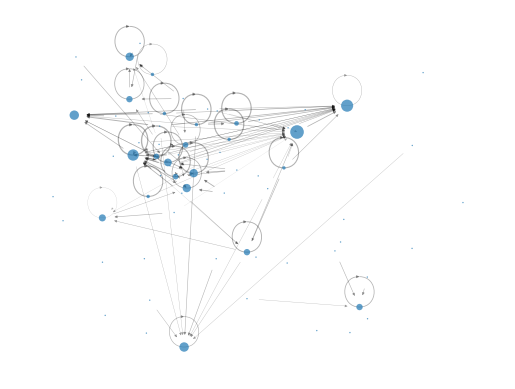

In [35]:
ax = plt.subplot()
plot_flow_graph(g_per_week[0], ax, pos=pos_all_weeks, with_labels=False)
ax.set_xlim(xlim_all_weeks)
ax.set_ylim(ylim_all_weeks);

(np.float64(0.0), np.float64(1.0), np.float64(0.0), np.float64(1.0))

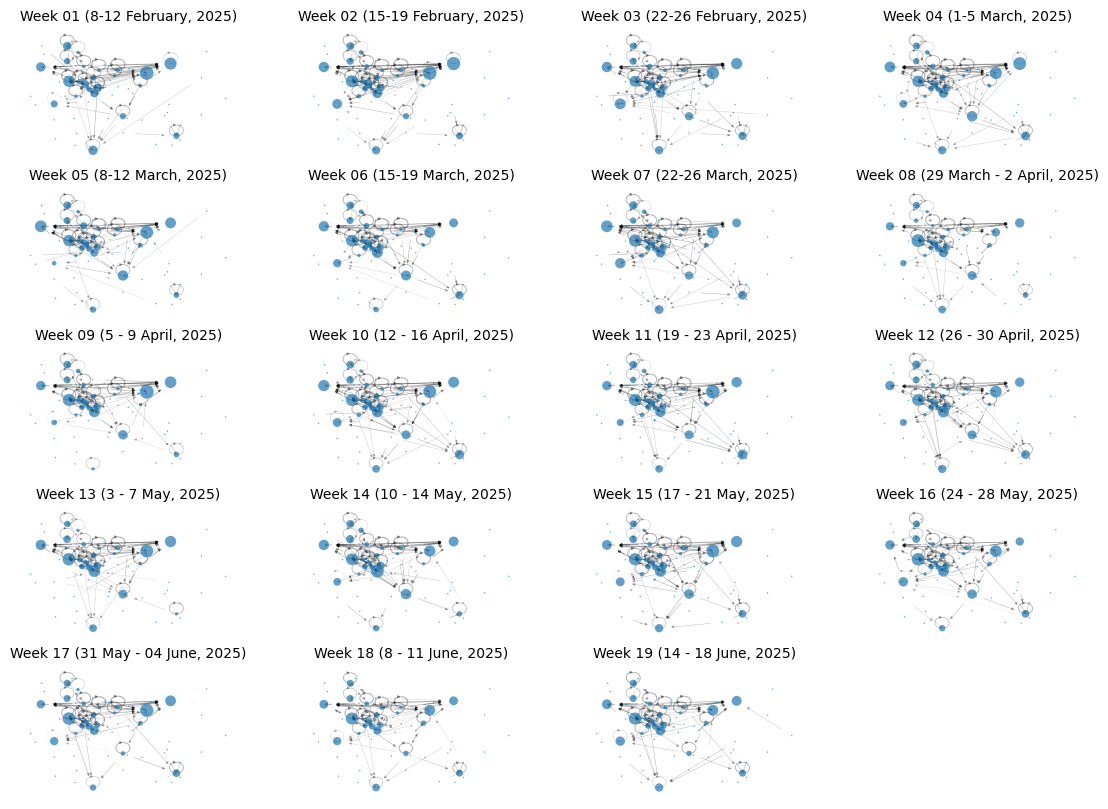

In [36]:
fig, axs = plt.subplots(len(weeks) // 4 + 1, 4, figsize=(14,10))
axs_flat = axs.flatten()

for i, g in enumerate(g_per_week) :
    ax = axs_flat[i]
    plot_flow_graph(g, ax, pos=pos_all_weeks, with_labels=False)
    ax.set_title(weeks[i], size=10)
    ax.set(xlim=xlim_all_weeks, ylim=ylim_all_weeks)

axs_flat[-1].axis('off')

MovieWriter ffmpeg unavailable; using Pillow instead.


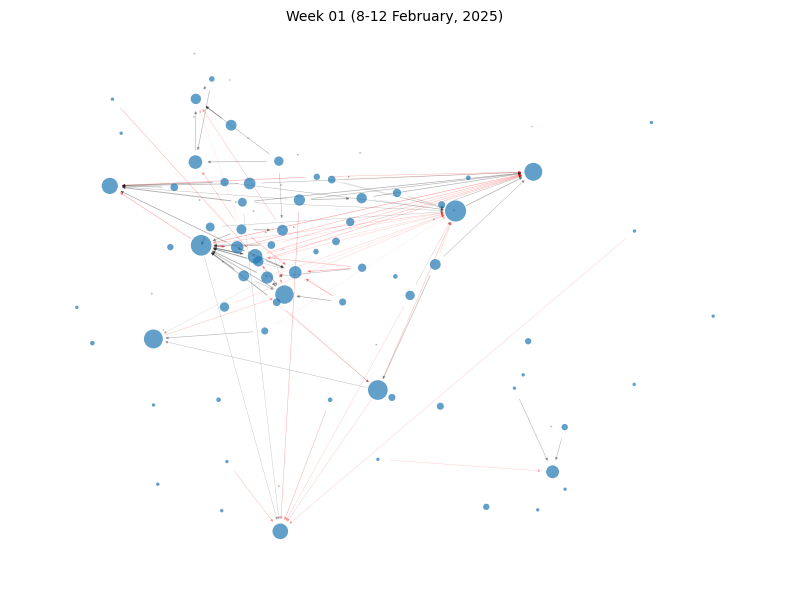

In [37]:
from matplotlib import animation

fig, ax = plt.subplots(1, figsize=(8,6), layout='tight')

def update(i_frame):
    ax.clear()

    g = g_per_week[i_frame]
    try :
        g_prev = g_per_week[i_frame-1]
        edge_colors = ['red' if e not in g_prev.edges() else 'black' for e in g.edges()]
    except IndexError :
        edge_colors = None

    plot_flow_graph(g, ax, pos=pos_all_weeks, with_labels=False, node_sizes=node_sizes_all_weeks, edge_colors=edge_colors, no_self_loops=True)

    ax.set_title(weeks[i_frame], size=10)

    ax.set(xlim=xlim_all_weeks, ylim=ylim_all_weeks)

ani = animation.FuncAnimation(fig, update, frames=len(weeks), interval=1000, repeat=True)

# plt.show()
ani.save('figs/weekly_flows_district.gif')

## Flows with GADM geolocation

In [84]:
# Import name mapping dict for geographical plotting
dtm_to_gadm_name = json.load(open('data/dtm_to_gadm_name.json', 'r'))

# Import GADM indeces and names
f = csv.reader(open('data/geo_labels_gadm.csv', 'r'))
gadm_name_and_id = {row[1]: int(row[0]) for row in f}

In [ ]:
def merge_digraph_nodes(g, mapping):
    """
    Map node labels, combining nodes/edges as necessary. 
    
    mapping (dict) : {old_node_label : new_node_label}
     
    If a node label is not in the mapping, it is unchanged. 
    If multiple nodes are mapped to the same new node label, their edges are combined and weights summed.
    """
    h = nx.DiGraph()

    # Ensure all mapped/unchanged nodes exist
    for n in g.nodes():
        h.add_node(mapping.get(n, n))

    # Redirect every edge through the merged nodes and sum weights
    for u, v, data in g.edges(data=True):
        u_new = mapping.get(u, u)   # By default, keep same label
        v_new = mapping.get(v, v)
        w = data.get("weight", 1)

        if h.has_edge(u_new, v_new):
            h[u_new][v_new]["weight"] += w
        else:
            h.add_edge(u_new, v_new, weight=w)

    return h

g_all_weeks_merged = merge_digraph_nodes(g_all_weeks, dtm_to_gadm_name)
g_all_weeks_merged

In [85]:
# Add missing nodes for consistence with GADM labels
for name in gadm_name_and_id:
    if name not in g_all_weeks_merged.nodes():
        g_all_weeks_merged.add_node(name)

In [87]:
gdf_gadm[gdf_gadm['NAME_2'] == 'Wajid']['centroid']

7    POINT (-342316.943 424914.394)
Name: centroid, dtype: geometry

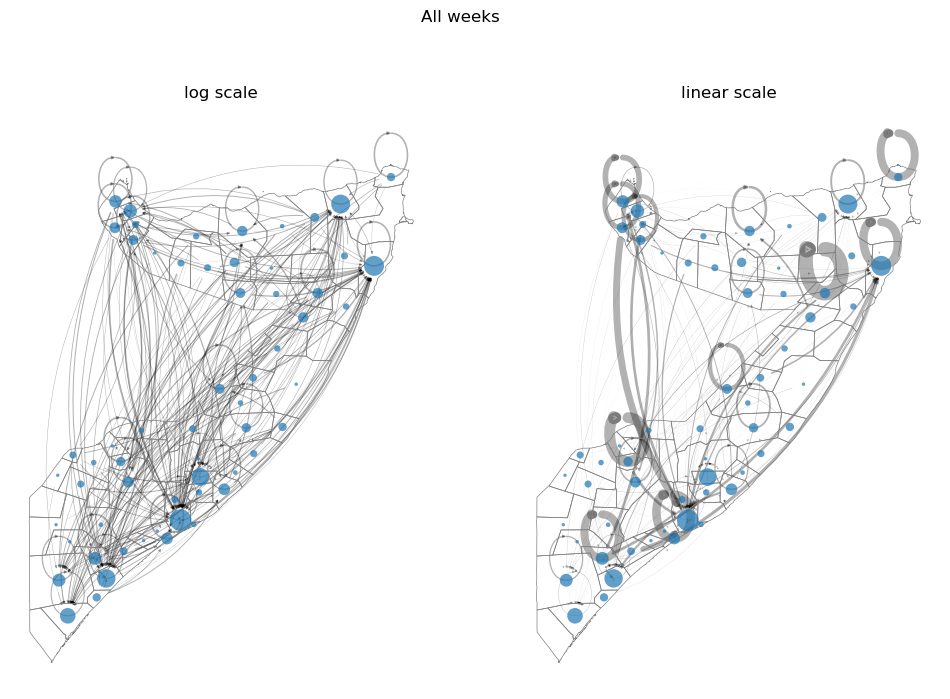

In [ ]:
fig, axs = plt.subplots(1, 2, figsize=(12,8))

pos = {}
for district in g_all_weeks_merged.nodes() :
    
    point = gdf_gadm[gdf_gadm['NAME_2'] == district]['centroid']
    pos[district] = (point.x.values[0], point.y.values[0])
    # pos[district] = (point.x, point.y)

node_sizes_all_weeks = [1 + g_all_weeks_merged.degree(n) * 5 for n in g_all_weeks_merged.nodes()]

# Log-scale
ax = axs[0]
gdf_gadm.boundary.plot(ax=ax, linewidth=0.5, color='gray')  # TODO: color in territory based on node in-degree, instead of drawing nodes with different sizes
# gdf_gadm.set_geometry('centroid').plot(ax=ax, markersize=4)
plot_flow_graph(g_all_weeks_merged, ax, pos=pos, 
                node_sizes=node_sizes_all_weeks,
                with_labels=False,
                edge_params={
                    'alpha': 0.3,
                    'connectionstyle': 'arc3,rad=0.2'
                },
)
ax.set(title="log scale")

# Linear scale
ax = axs[1]
gdf_gadm.boundary.plot(ax=ax, linewidth=0.5, color='gray')
plot_flow_graph(g_all_weeks_merged, ax, pos=pos, 
                node_sizes=node_sizes_all_weeks,
                with_labels=False,
                edge_width_func=lambda w : w / 2000,
                edge_params={
                    'alpha': 0.3,
                    'connectionstyle': 'arc3,rad=0.2',
                    # 'arrowsize': 0,
                },
)
ax.set(title="linear scale")

fig.suptitle('All weeks');

plt.savefig('figs/flows_all_geo.pdf', dpi=600, bbox_inches='tight')

Within-district migrations (self-loops) dominate the flows. What fraction of internal migrations are first vs e.g. third displacement?

In [88]:
# Save adjacency matrix of geographically-resolved flow graph, using GADM labels as indices
nodelist = gadm_name_and_id.keys()  # Python preserves insertion order, which in this case is also sorted by index
geo_flow_matrix = nx.adjacency_matrix(g_all_weeks_merged, weight='weight', nodelist=nodelist).todense()
np.savetxt('data/geo_flow_matrix.csv', geo_flow_matrix, fmt='%d', delimiter=',')

In [42]:
fig, ax = plt.subplots(1, figsize=(8,8))
gdf_gadm.boundary.plot(ax=ax, linewidth=0.5)
gdf_gadm.set_geometry('centroid').plot(
    ax=ax, 
    markersize=4
)

in_degrees = dict(g_all_weeks_merged.in_degree(weight='weight'))
out_degrees = dict(g_all_weeks_merged.out_degree(weight='weight'))
in_out_degree_diff = {n: int(in_degrees.get(n, 0) - out_degrees.get(n, 0)) for n in g_all_weeks_merged.nodes()}

cmap = mpl.colormaps['coolwarm']
norm = mpl.Normalize(vmin=-1000, vmax=1000)
district_colors = [ for name in gdf_gadm['NAME_2']]
# gdf_gadm.plot(
#     ax=ax,
#     # color=in_out_degree_diff.map(lambda x: 'green' if x > 0 else ('red' if x < 0 else 'gray'))
#     # color=in_out_degree_diff
#     # color=np.arange(74)
#     color=['black'] * 74
#     # color='black'
# )

# for idx, row in gdf_gadm.iterrows():
#     point = row['centroid']
#     x = point.x
#     y = point.y
#     ax.annotate(
#         idx, xy=(x,y), 
#         color='k', 
#         xycoords='data',
#         xytext=(-8, -8), 
#         textcoords='offset points', 
#         fontsize=7
#     )

SyntaxError: invalid syntax (1403765712.py, line 14)

In [ ]:
in_out_degree_diff

{'Wajid': -1422,
 'BuuloBurdo': -987,
 'Diinsoor': -9435,
 'Xudur': -2001,
 'Garoowe': 895,
 'Aadan': -5962,
 'Balcad': -3097,
 'Saakow': -1835,
 'QansaxDheere': -5248,
 'Qoryooley': -8831,
 'BeledWeyn': 1038,
 'Baar-Dheere': 7286,
 'Baydhabo': 14203,
 "Bu'aale": -1597,
 'Jalalaqsi': -833,
 'Jamaame': -2621,
 'Gaalkacayo': 1758,
 'Afgooye': -6749,
 'Jawhar': -4091,
 'CeelDheer': -225,
 'Caabudwaaq': -102,
 'Luuk': -4938,
 'Kismaayo': 3437,
 'RabDhuure': -1416,
 'Kuntuwaaray': -1315,
 'Cadale': -544,
 'BuurXakaba': -3250,
 'Badhaadhe': -521,
 'CeelBarde': -374,
 'CeelBuur': -564,
 'Garbahaaray': -484,
 'Tiyeeglow': -906,
 'Afmadow': 603,
 'Dhuusamareeb': 860,
 'BeledXaawo': -184,
 'Mogadisho': 43316,
 'Hobyo': -376,
 'Marka': -5946,
 'Taleex': -36,
 'Jilib': -1019,
 'CeelWaaq': -1250,
 'Bosaaso': -90,
 'WanlaWeyn': -1957,
 'Baraawe': -232,
 'Dolow': 8795,
 'Sablale': -360,
 'Xarardheere': -394,
 'Jariiban': -201,
 'Ceerigaabo': -66,
 'Goldogob': -277,
 'Eyl': -114,
 'Qardho': -24,
 'Cad

In [ ]:
type(np.arange(74).tolist()[0])

int

In [ ]:
gdf_gadm

,GID_2,GID_0,COUNTRY,GID_1,NAME_1,NL_NAME_1,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2,geometry,centroid
0,SOM.1.1_1,SOM,Somalia,SOM.1_1,Awdal,NA,Aadan,NA,NA,District,District,NA,SO.AW.BA,"MULTIPOLYGON (((-258918.643 1178983.263, -2583...",POINT (-297818.987 1143950.621)
1,SOM.1.2_1,SOM,Somalia,SOM.1_1,Awdal,NA,Afgooye,Boramo|Borama,NA,District,District,NA,SO.AW.BO,"MULTIPOLYGON (((-346944.62 1076389.937, -34730...",POINT (-360144.965 1134011.013)
2,SOM.1.3_1,SOM,Somalia,SOM.1_1,Awdal,NA,Afmadow,Lughaye,NA,District,District,NA,SO.AW.LU,"MULTIPOLYGON (((-258918.643 1178983.263, -3287...",POINT (-313798.554 1184798.15)
3,SOM.1.4_1,SOM,Somalia,SOM.1_1,Awdal,NA,Baar-Dheere,Saylac,NA,District,District,NA,SO.AW.ZE,"MULTIPOLYGON (((-324555.621 1265736.823, -3240...",POINT (-358373.583 1213809.07)
4,SOM.2.1_1,SOM,Somalia,SOM.2_1,Bakool,NA,Badhaadhe,CeelBarde|ElBarde,NA,District,District,NA,SO.BK.CB,"MULTIPOLYGON (((-376869.554 515682.202, -37312...",POINT (-279257.958 519284.885)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,SOM.17.3_1,SOM,Somalia,SOM.17_1,Togdheer,NA,WanlaWeyn,Odwenyen|Oodwayne|Odweine,NA,District,District,NA,SO.TO.OD,"MULTIPOLYGON (((-131730.11 951116.412, -195345...",POINT (-159959.155 1026964.34)
70,SOM.17.4_1,SOM,Somalia,SOM.17_1,Togdheer,NA,Xarardheere,Sheik|Sheikh,NA,District,District,NA,SO.TO.SH,"MULTIPOLYGON (((-59391.488 1120791.529, -69413...",POINT (-113732.509 1107999.133)
71,SOM.18.1_1,SOM,Somalia,SOM.18_1,WoqooyiGalbeed,NA,Xudun,NA,NA,District,District,NA,SO.WO.BE,"MULTIPOLYGON (((-252772.552 1145502.818, -2418...",POINT (-129200.762 1149808.198)
72,SOM.18.2_1,SOM,Somalia,SOM.18_1,WoqooyiGalbeed,NA,Xudur,Gebiley,NA,District,District,NA,SO.WO.GE,"MULTIPOLYGON (((-334772.552 1056663.031, -3358...",POINT (-304235.535 1096761.786)


In [ ]:
dict(g_all_weeks_merged.in_degree).values()

dict_values([3, 4, 8, 3, 24, 0, 3, 0, 5, 0, 30, 9, 32, 3, 0, 4, 13, 7, 2, 0, 3, 8, 7, 0, 0, 0, 0, 0, 0, 0, 0, 0, 14, 26, 1, 42, 0, 0, 0, 0, 0, 0, 0, 0, 31, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
g_all_weeks_merged.nodes(data=True)

NodeDataView({'Wajid': {}, 'BuuloBurdo': {}, 'Diinsoor': {}, 'Xudur': {}, 'Garoowe': {}, 'Aadan': {}, 'Balcad': {}, 'Saakow': {}, 'QansaxDheere': {}, 'Qoryooley': {}, 'BeledWeyn': {}, 'Baar-Dheere': {}, 'Baydhabo': {}, "Bu'aale": {}, 'Jalalaqsi': {}, 'Jamaame': {}, 'Gaalkacayo': {}, 'Afgooye': {}, 'Jawhar': {}, 'CeelDheer': {}, 'Caabudwaaq': {}, 'Luuk': {}, 'Kismaayo': {}, 'RabDhuure': {}, 'Kuntuwaaray': {}, 'Cadale': {}, 'BuurXakaba': {}, 'Badhaadhe': {}, 'CeelBarde': {}, 'CeelBuur': {}, 'Garbahaaray': {}, 'Tiyeeglow': {}, 'Afmadow': {}, 'Dhuusamareeb': {}, 'BeledXaawo': {}, 'Mogadisho': {}, 'Hobyo': {}, 'Marka': {}, 'Taleex': {}, 'Jilib': {}, 'CeelWaaq': {}, 'Bosaaso': {}, 'WanlaWeyn': {}, 'Baraawe': {}, 'Dolow': {}, 'Sablale': {}, 'Xarardheere': {}, 'Jariiban': {}, 'Ceerigaabo': {}, 'Goldogob': {}, 'Eyl': {}, 'Qardho': {}, 'Cadaado': {}, 'Badhan': {}, 'Burtinle': {}, 'Lascaanod': {}, 'Qandala': {}, 'Zeylac': {}, 'Calawla': {}, 'Caynabo': {}})

# DTM api

The DTM has an API that you can use to get data by country, admin level, timeframe, etc... 

While it gives us IDPs that move to a given district, unfortunately (as you see below) it only gives the region (admin level 1) as origin, so we could not use it to analyze flows on the level of districts.

DTM API [homepage](https://dtm.iom.int/data-and-analysis/dtm-api)

PyPI [package](https://pypi.org/project/dtmapi/) and [documentation](https://dtmapi.readthedocs.io/en/latest/dtmapi.html#dtmapi.DTMApi)

[User profile](https://dtm-apim-portal.iom.int/profile)

In [ ]:
from dtmapi import DTMApi

with open('dtm_api_key.txt', 'r') as f:
    api_key = f.read()

# Instantiate the API client with your subscription key.
api = DTMApi(subscription_key=api_key)

In [ ]:
all_country_list = api.get_all_countries()
all_country_list.head(10)

In [ ]:
all_country_list[all_country_list['admin0Name'] == 'Somalia']

In [ ]:
len(all_country_list)

In [ ]:
all_operation_list = api.get_all_operations()
all_operation_list.head()


In [ ]:
all_operation_list[all_operation_list['admin0Name'] == 'Somalia']

In [ ]:
idp_admin2_data = api.get_idp_admin2_data(Operation="Somalia displacement", CountryName='Somalia')
idp_admin2_data.sort_values(by=['reportingDate'], ascending=False)

In [ ]:
idp_admin2_data = api.get_idp_admin2_data(CountryName='Somalia')
idp_admin2_data.sort_values(by=['reportingDate'], ascending=False)

^ IDP numbers are reported only based on admin 1 (regions) as origin.

In [ ]:
admin2_name_and_pcode = idp_admin2_data[['admin2Name', 'admin2Pcode']]
admin2_name_and_pcode

In [ ]:
districts_api = admin2_name_and_pcode['admin2Name'].unique()
len(districts_api)

In [ ]:
districts_api.sort()
print(districts_api)

In [ ]:
d = np.array(districts_dtm)
d.sort()
print(d)

In [ ]:
# Match districts in DTM from API to dataset

from Levenshtein import distance as edit_distance

district_matches_api = {}

for district_name in districts_api :
    distances_to_dtm_names = {x : edit_distance(district_name, x) for x in districts_dtm}
    closest_match, d = min(distances_to_dtm_names.items(), key=lambda x : x[1])
    district_matches_api[district_name] = (closest_match, d)

# Print all matches
# close_matches = {name : match for name, match in district_matches_wb.items() if 0 <= match[1] <= 3}
# print(f"Total of {len(close_matches)} ({len(close_matches)/len(districts_wb):.0%}) WB names have exact or close matches (0 <= d <= 3) in DTM:")
longest_name_length = len(max(district_matches_api.keys(), key=len))
for name, match in sorted(district_matches_api.items(), key=lambda x: x[1][1]):
    print(f"{name:<{longest_name_length}} --> {match[0]:<15} (d = {match[1]})")